# Task 9 — Feature Engineering
## Step 6: Feature Selection

**Goal:** Identify and retain only the most informative features,
removing redundant, low-variance, or highly correlated ones.

**Techniques used:**
- Correlation heatmap — identify multicollinearity
- SelectKBest (chi2) — statistical feature scoring
- Feature importance via ExtraTreesClassifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.ensemble import ExtraTreesClassifier

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/cleaned_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1309, 8)


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


### 6.1 Separate Features and Target

In [2]:
X = df.drop(columns=['Survived'])
y = df['Survived']
print(f'Features: {X.shape[1]} | Target: Survived')
print(f'Feature columns: {list(X.columns)}')

Features: 7 | Target: Survived
Feature columns: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']


### 6.2 Correlation Heatmap

Visualizes linear correlations between all features and the target.
Features highly correlated with each other (> 0.8) are candidates for removal.

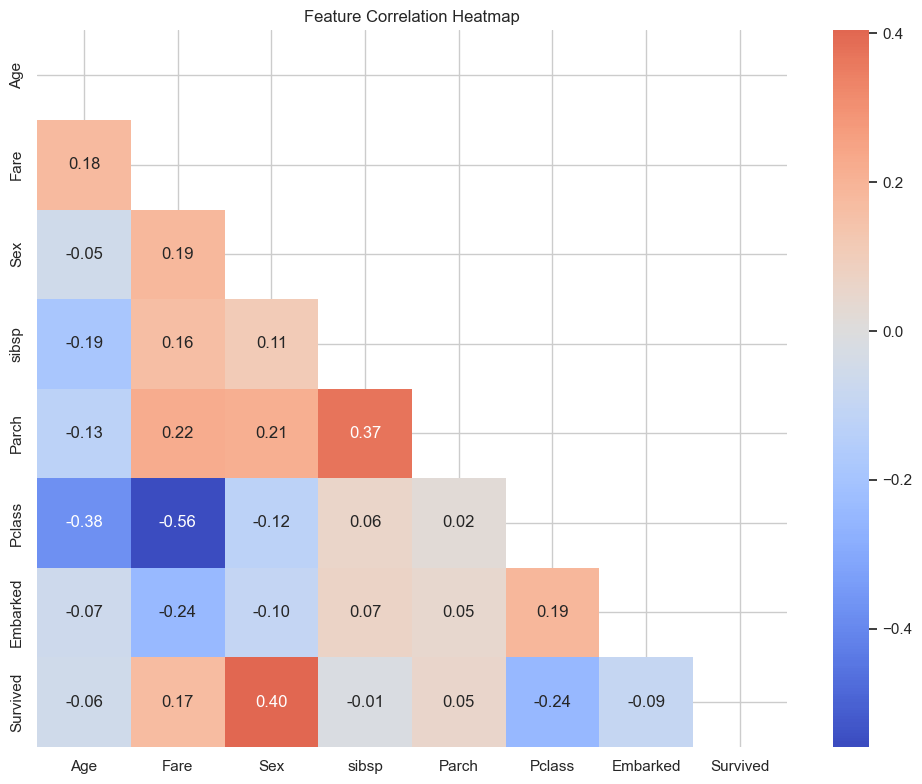

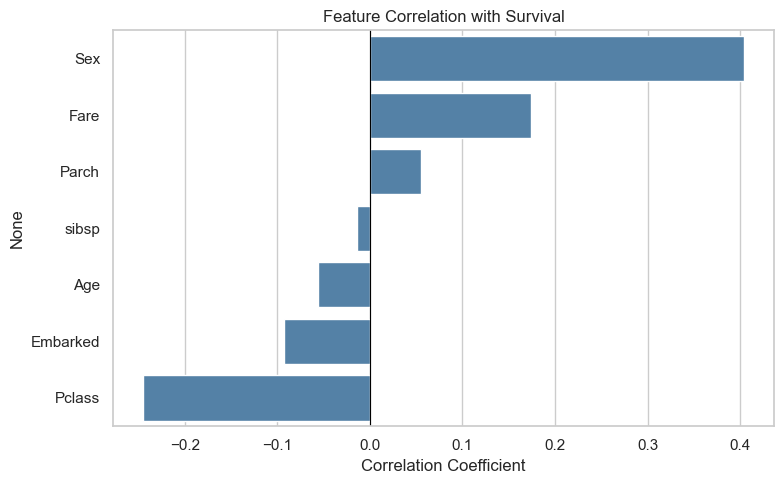

In [3]:
# 1. Calculate correlations (safely ignoring any stray non-numeric columns)
corr = df.corr(numeric_only=True)

# 2. Plot the Heatmap (Masked)
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 3. Plot Correlation specifically with the Target ('Survived')
plt.figure(figsize=(8, 5))
target_corr = corr['Survived'].drop('Survived').sort_values(ascending=False)

# A horizontal bar plot is much easier to read than a printed list
sns.barplot(x=target_corr.values, y=target_corr.index, color='steelblue')
plt.title('Feature Correlation with Survival')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8) # Adds a line at 0 for reference
plt.tight_layout()
plt.show()

### 6.3 Drop Highly Correlated Features

If two features have correlation > 0.85, drop the one with
lower correlation to the target.

In [4]:
# 1. Calculate absolute correlation matrix (ignoring any stray text columns)
corr_matrix = X.corr(numeric_only=True).abs()

# 2. Mask the bottom half and diagonal to avoid self-correlation (1.0) and duplicate pairs
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Find columns where any correlation exceeds the 0.85 threshold
cols_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.85)]

# 4. Drop the redundant features
if cols_to_drop:
    print(f"Dropping redundant features (correlation > 0.85): {cols_to_drop}")
    X.drop(columns=cols_to_drop, inplace=True)
else:
    print("No highly correlated feature pairs found (threshold: 0.85).")

No highly correlated feature pairs found (threshold: 0.85).


### 6.4 SelectKBest — Statistical Feature Scoring.

In [7]:
# 1. Define your features (X) and target (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

# 2. Check for missing values
missing_counts = X.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0]

# 3. Apply the Safety Net
if not cols_with_missing.empty:
    print("Found missing values in these columns:")
    print(cols_with_missing)
    print("\nApplying median imputation safety net...\n")
    X = X.fillna(X.median(numeric_only=True))
    print("Missing values patched!")
else:
    print("No missing values found! Ready for Feature Selection.")

Found missing values in these columns:
Embarked    2
dtype: int64

Applying median imputation safety net...

Missing values patched!


In [8]:
# 1. Fit SelectKBest (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# 2. Create a sorted dataframe of scores
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("--- Feature Statistical Importance ---")
print(scores_df.round(4).to_string(index=False))

--- Feature Statistical Importance ---
 Feature  F-Score  P-Value
     Sex 254.9626   0.0000
  Pclass  83.2348   0.0000
    Fare  40.7029   0.0000
Embarked  11.0092   0.0009
     Age   4.0913   0.0433
   Parch   3.9524   0.0470
   sibsp   0.2702   0.6033


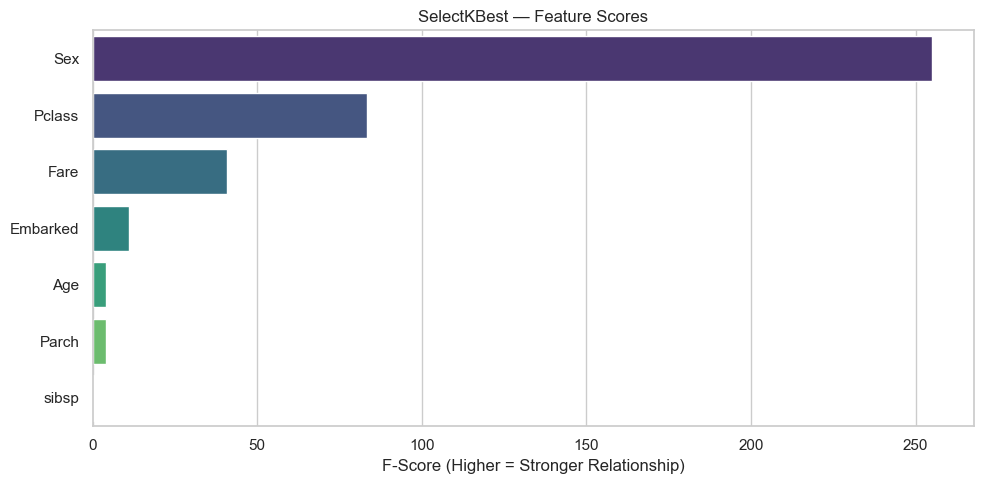

In [9]:
plt.figure(figsize=(10, 5))

# hue='Feature' and legend=False prevent deprecation warnings in newer Seaborn versions
sns.barplot(data=scores_df, x='F-Score', y='Feature', hue='Feature', palette='viridis', legend=False)

plt.title('SelectKBest — Feature Scores')
plt.xlabel('F-Score (Higher = Stronger Relationship)')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 6.5 Feature Importance — ExtraTreesClassifier

Tree-based importance gives a non-linear view of feature relevance,
complementing the statistical scores above.

--- Tree-Based Feature Importance ---
 Feature  Importance
     Age      0.3367
    Fare      0.2962
     Sex      0.1739
  Pclass      0.0714
   Parch      0.0501
   sibsp      0.0466
Embarked      0.0251


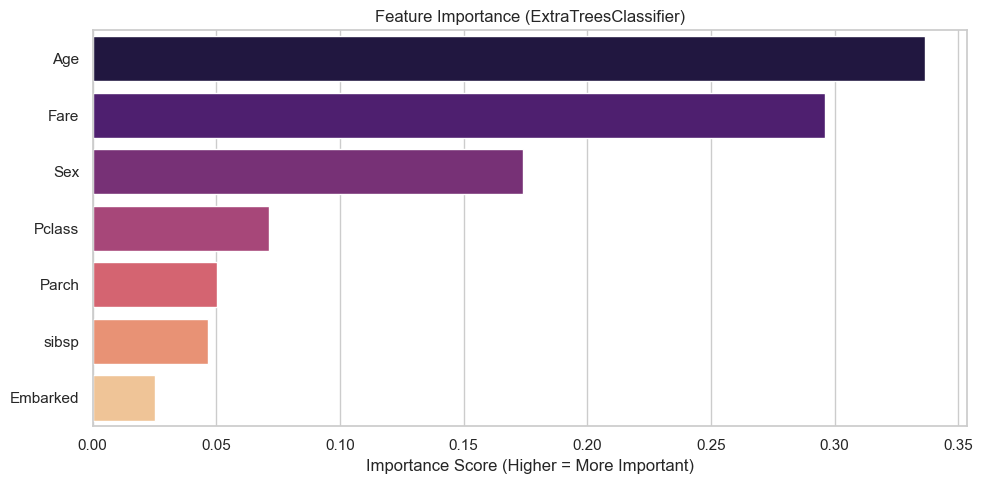

In [10]:
# 1. Initialize and Fit the Model
model = ExtraTreesClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 2. Extract and Sort Feature Importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("--- Tree-Based Feature Importance ---")
print(importance_df.round(4).to_string(index=False))

# 3. Visualize the Importances
plt.figure(figsize=(10, 5))

# Added hue='Feature' and legend=False to prevent Seaborn warnings
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)

plt.title('Feature Importance (ExtraTreesClassifier)')
plt.xlabel('Importance Score (Higher = More Important)')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 6.6 Select Final Features

Based on both SelectKBest scores and tree-based importance,
retain the top features. Drop low-signal features (SibSp, Parch
individually since FamilySize captures them).

In [11]:
drop_low_signal = ['SibSp', 'Parch']
existing_to_drop = [col for col in drop_low_signal if col in X.columns]
X_final = X.drop(columns=existing_to_drop)

print(f'Dropped low-signal features: {existing_to_drop}')
print(f'Final feature set ({X_final.shape[1]} features): {list(X_final.columns)}')

Dropped low-signal features: ['Parch']
Final feature set (6 features): ['Age', 'Fare', 'Sex', 'sibsp', 'Pclass', 'Embarked']


### 6.7 Before vs After — Feature Count Summary

In [17]:
# 1. Provide the exact Windows path to your raw data (using the 'r' prefix!)
raw_path = r'E:\summer-internship-2026-InfyChain-Kinari-Thummar\Week-3_Machine_Learning\Task9_Feature_Engineering\data\titanic.csv'

try:
    # Read the raw file to get the starting feature count
    raw_features = pd.read_csv(raw_path).shape[1] - 1  # minus target
    print(f'Features in raw dataset       : {raw_features}')
except FileNotFoundError:
    print(f"Error: Could not find the file at {raw_path}")
    print("Please check that the file name exactly matches what is in your folder!")

# 2. Print features after cleaning (using your main 'df')
print(f'Features after cleaning       : {df.shape[1] - 1}')

# 3. Print final features
# Note: In our previous steps, we modified 'X' directly. 
# If you didn't create a specific variable named 'X_final', we will just use 'X' here!
X_final = X 

print(f'Features after selection      : {X_final.shape[1]}')
print(f'\nFinal feature list: {list(X_final.columns)}')

Features in raw dataset       : 27
Features after cleaning       : 7
Features after selection      : 7

Final feature list: ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']


### 6.8 Save Final Engineered Dataset

In [16]:
final_df = pd.concat([X_final, y], axis=1)
final_df.to_csv('../data/final_engineered.csv', index=False)
print(f'Final engineered dataset saved to data/final_engineered.csv')
print(f'Shape: {final_df.shape}')
final_df.head()

Final engineered dataset saved to data/final_engineered.csv
Shape: (1309, 8)


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0
